# 1 Avec 10 itérations

## Diagramme à ligne brisée

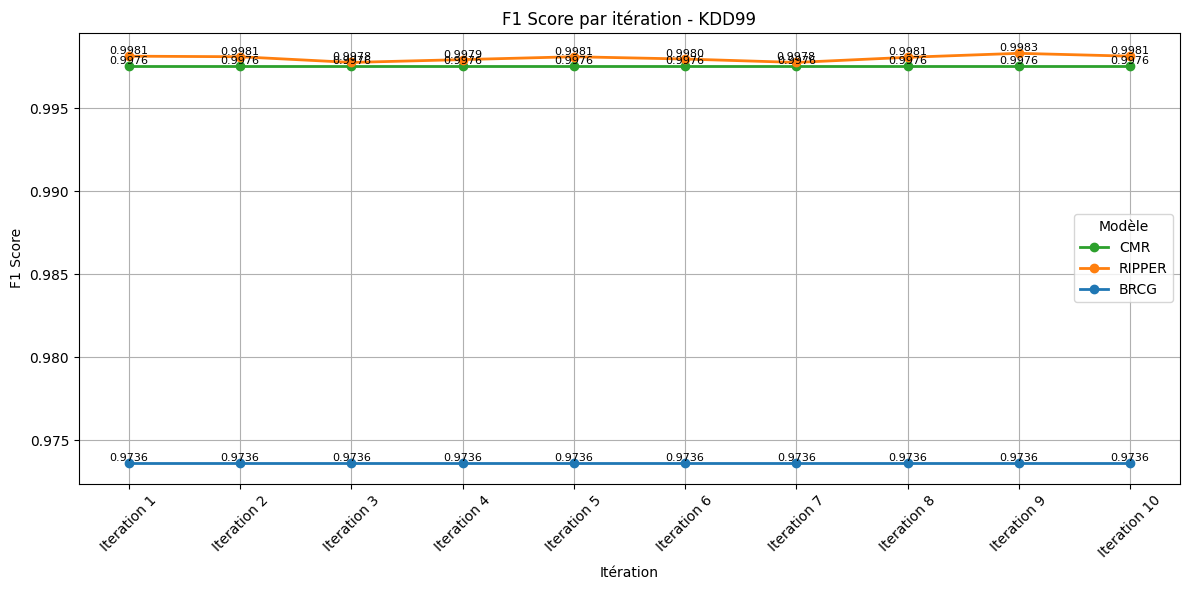

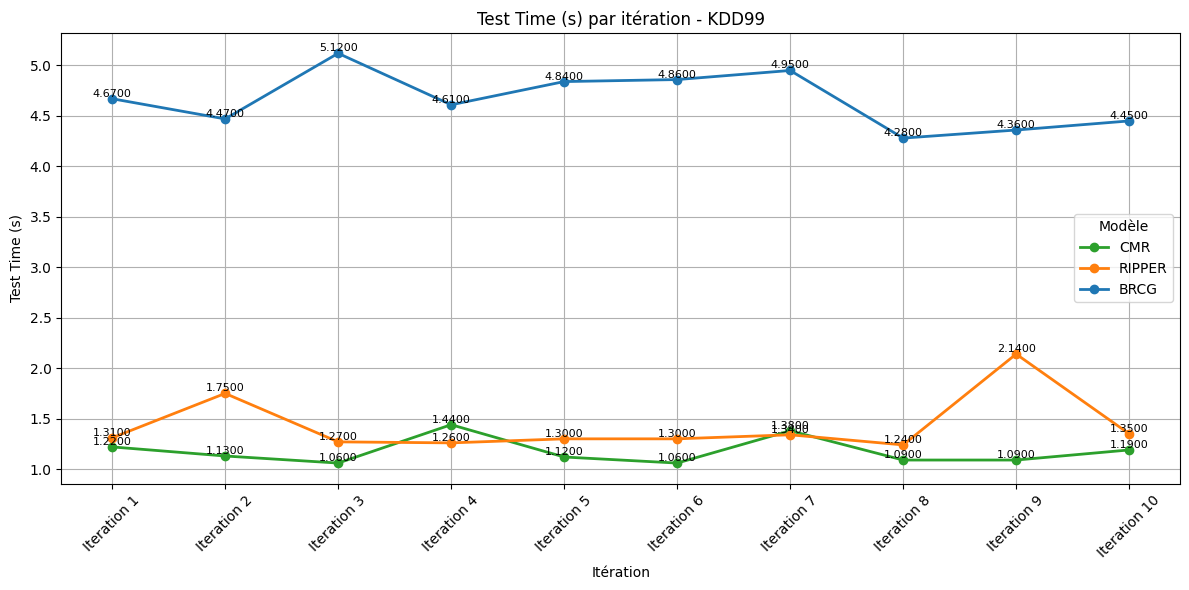

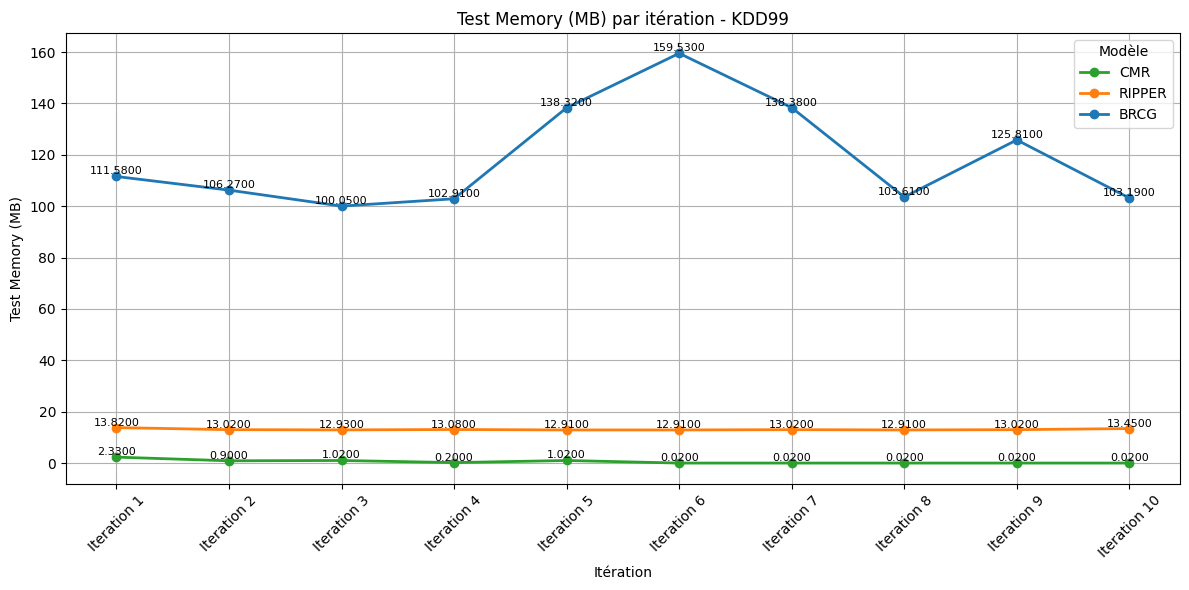

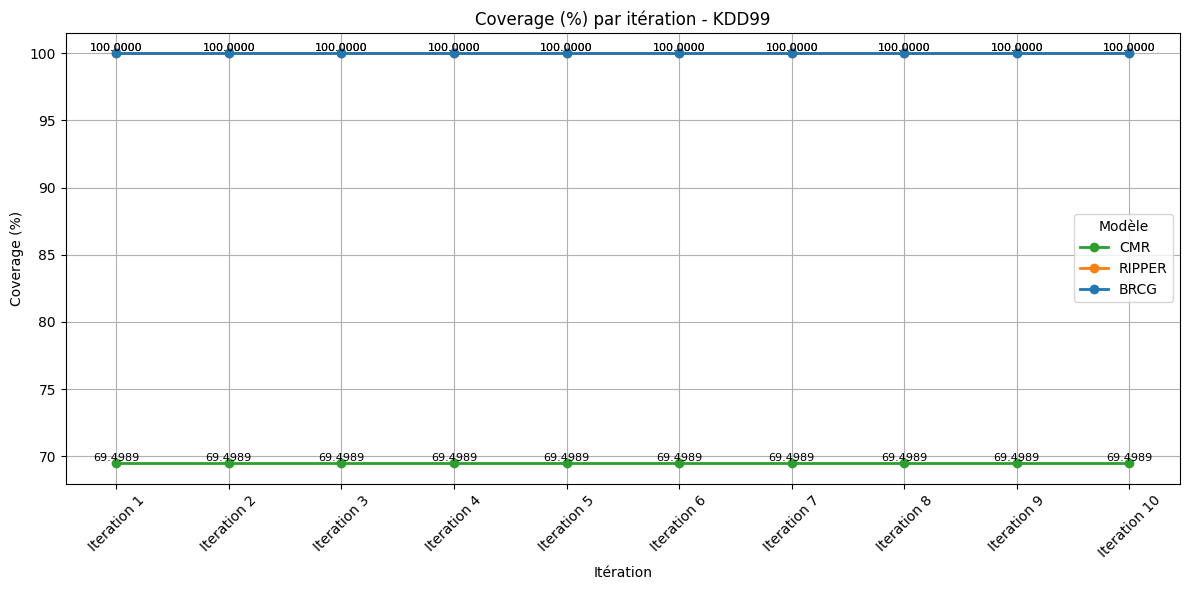

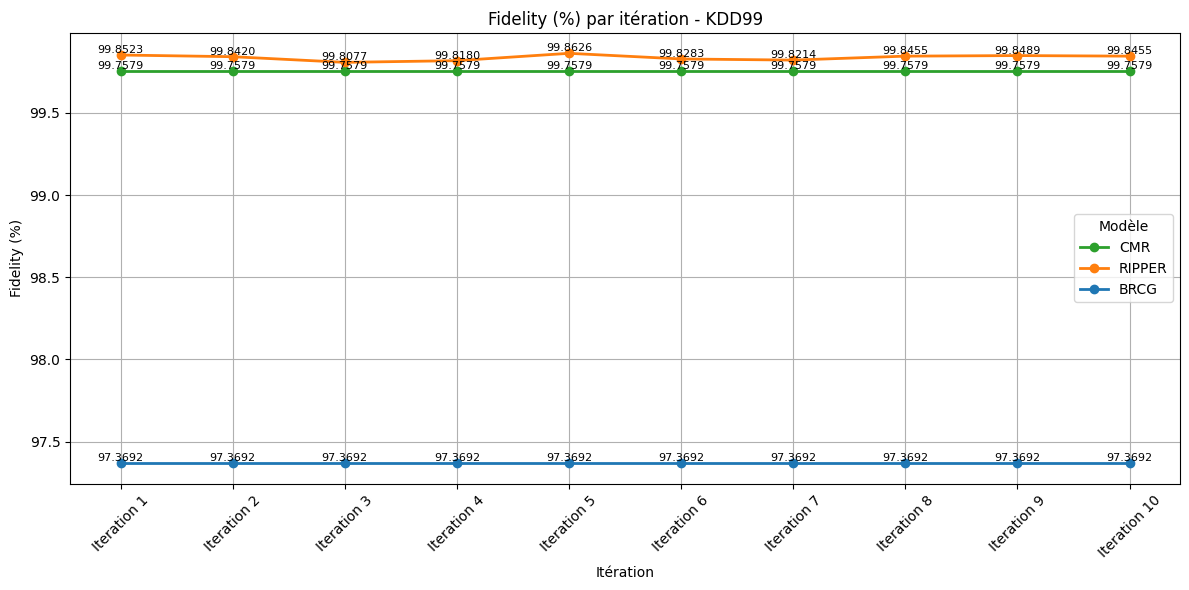

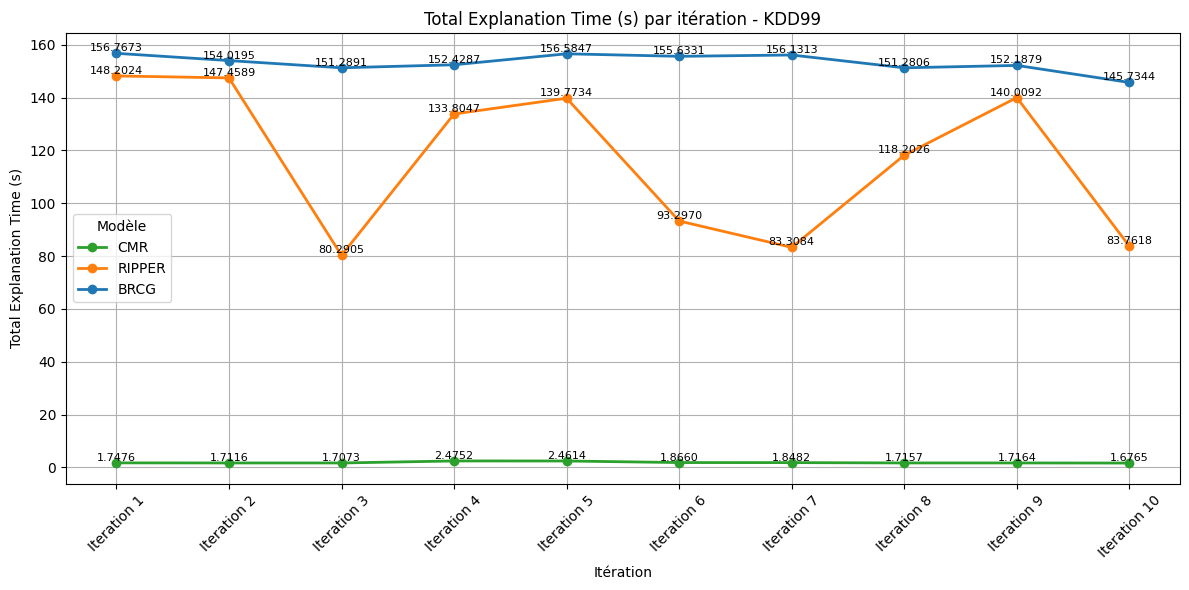

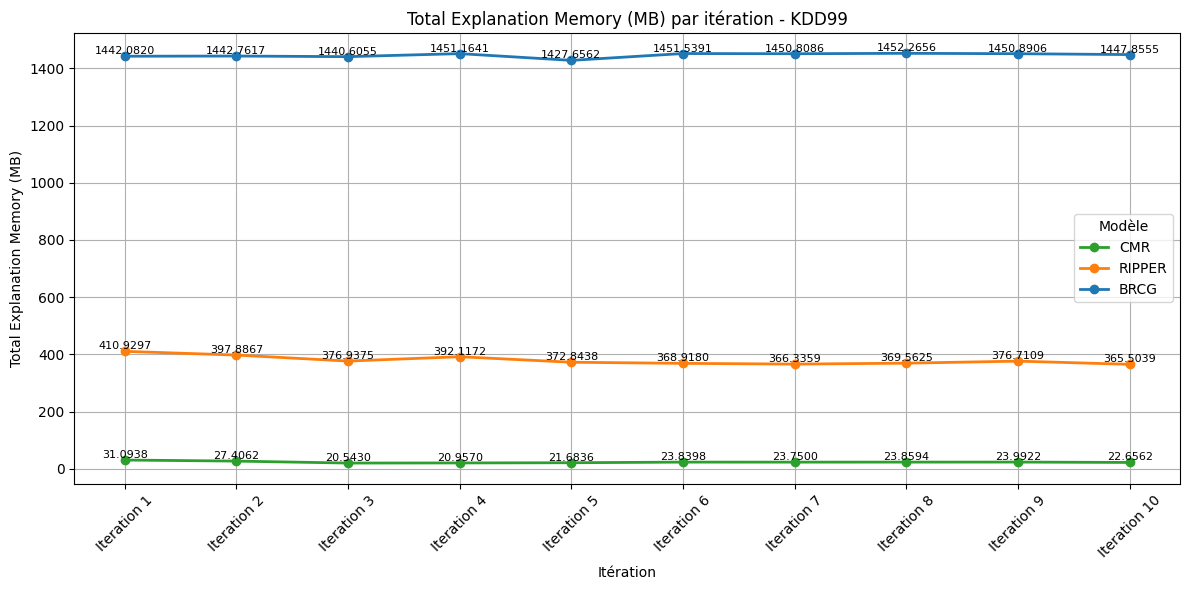

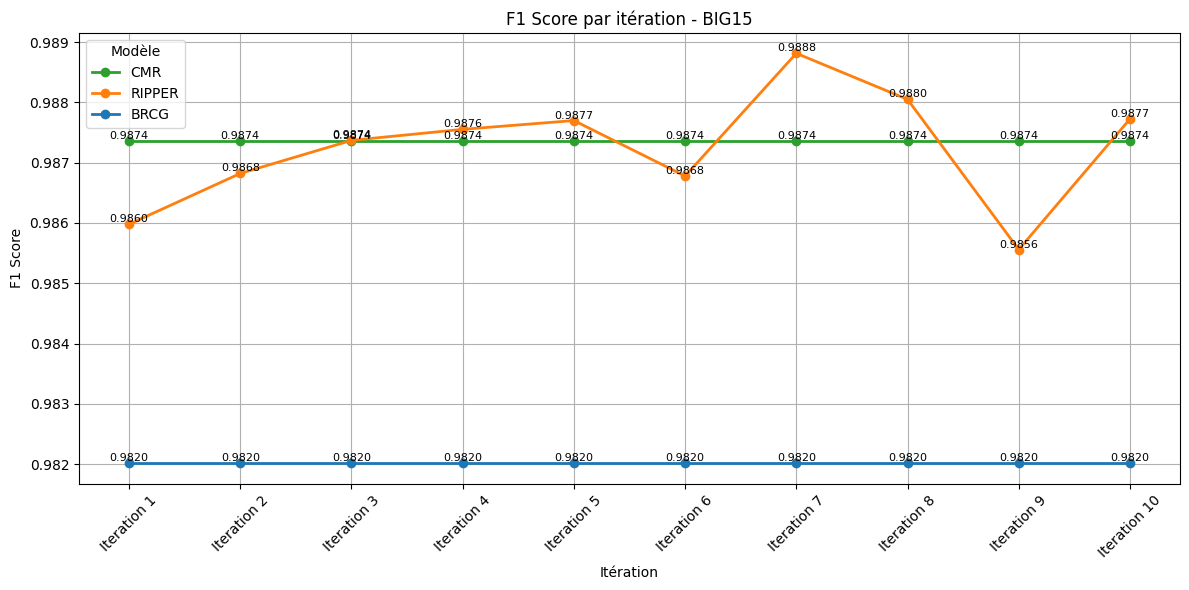

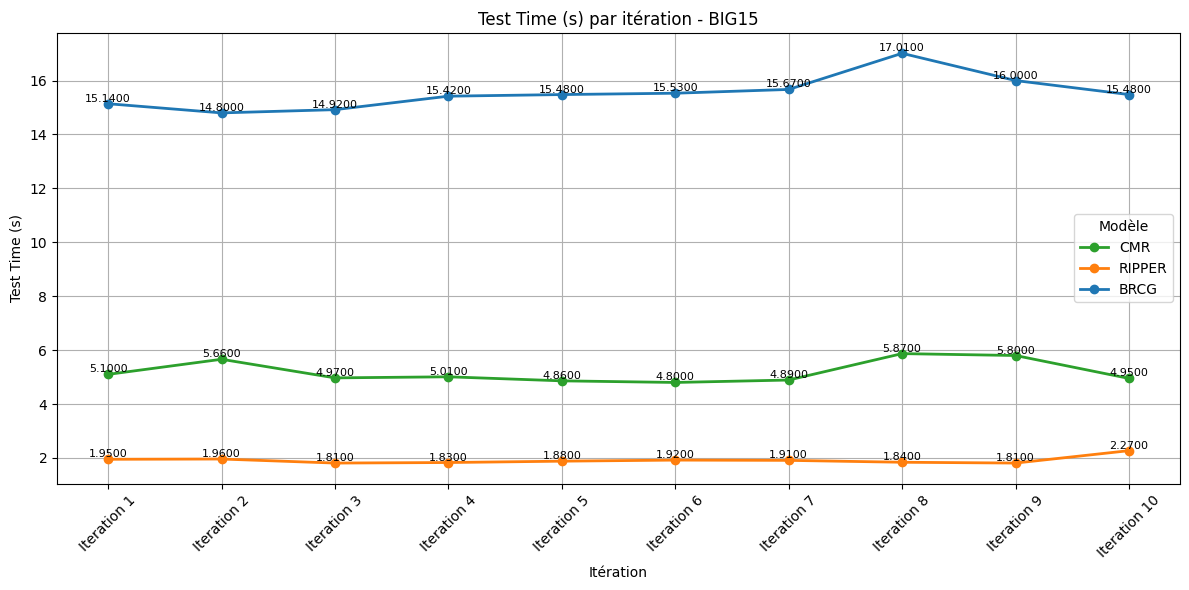

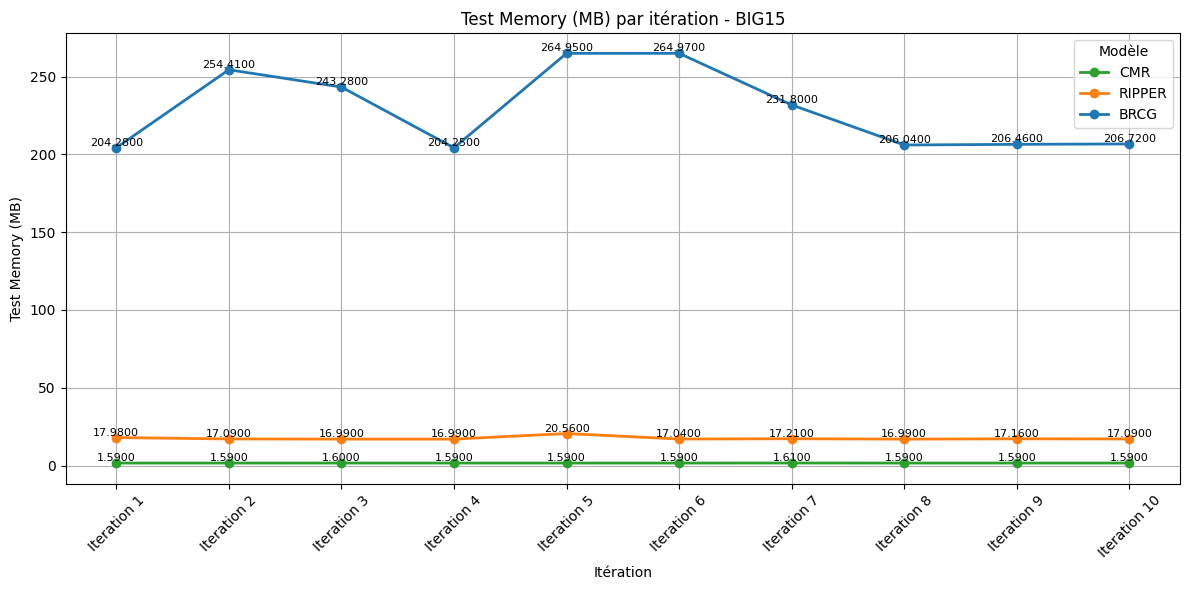

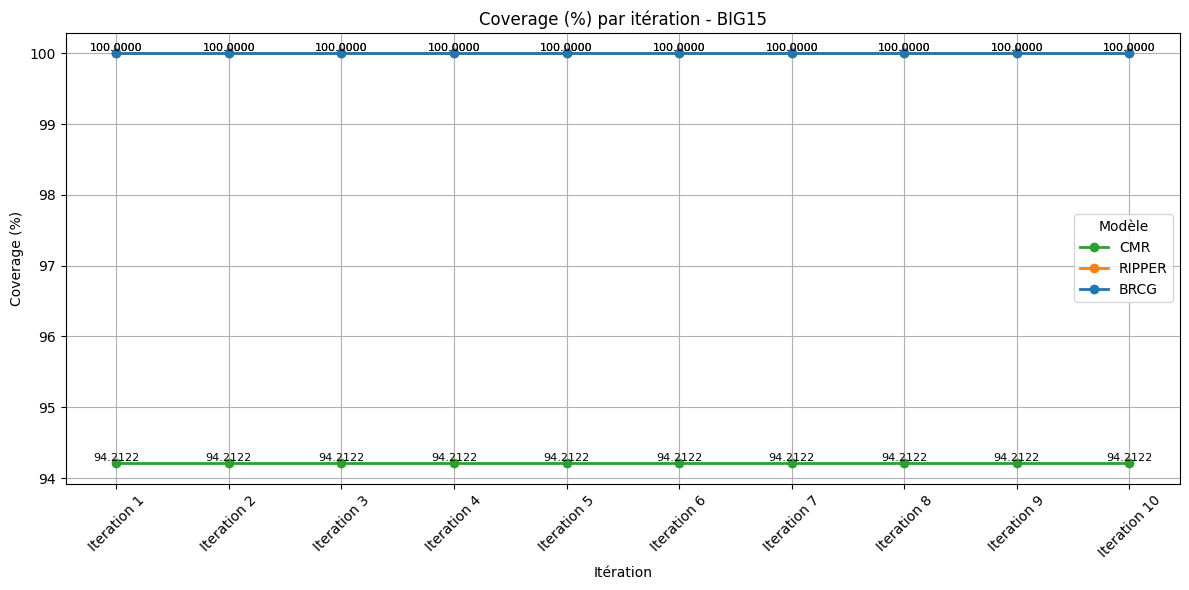

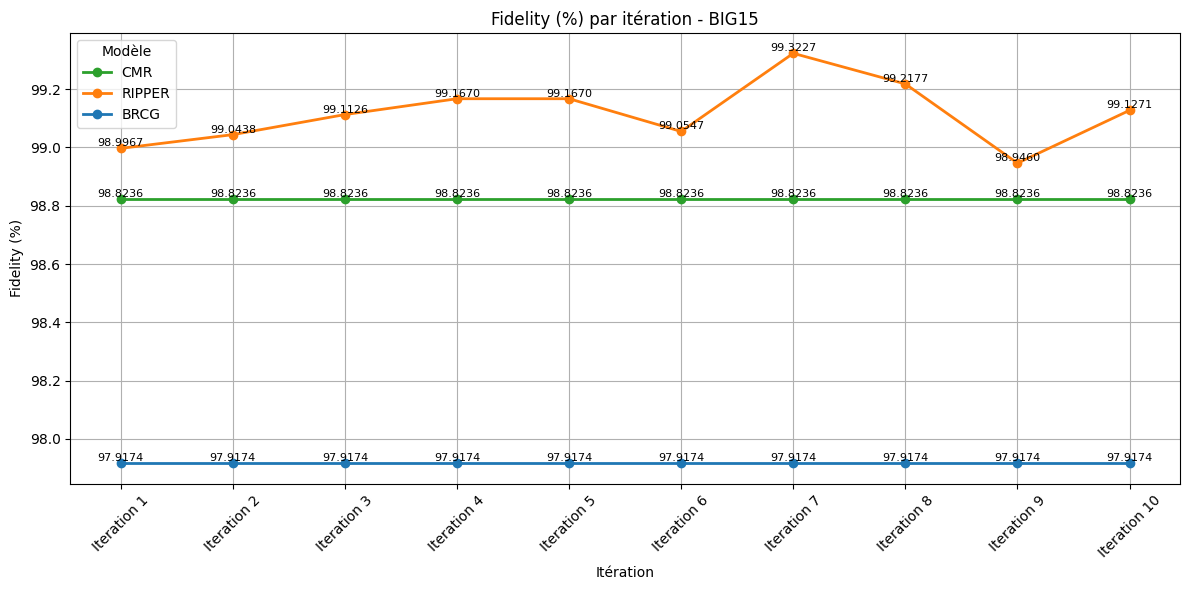

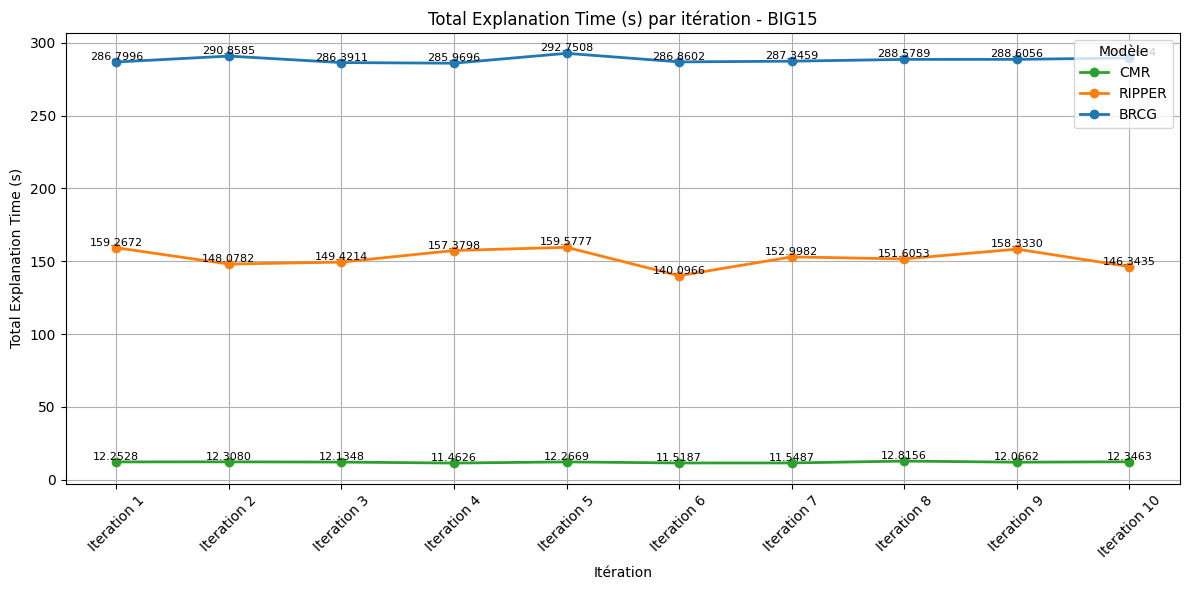

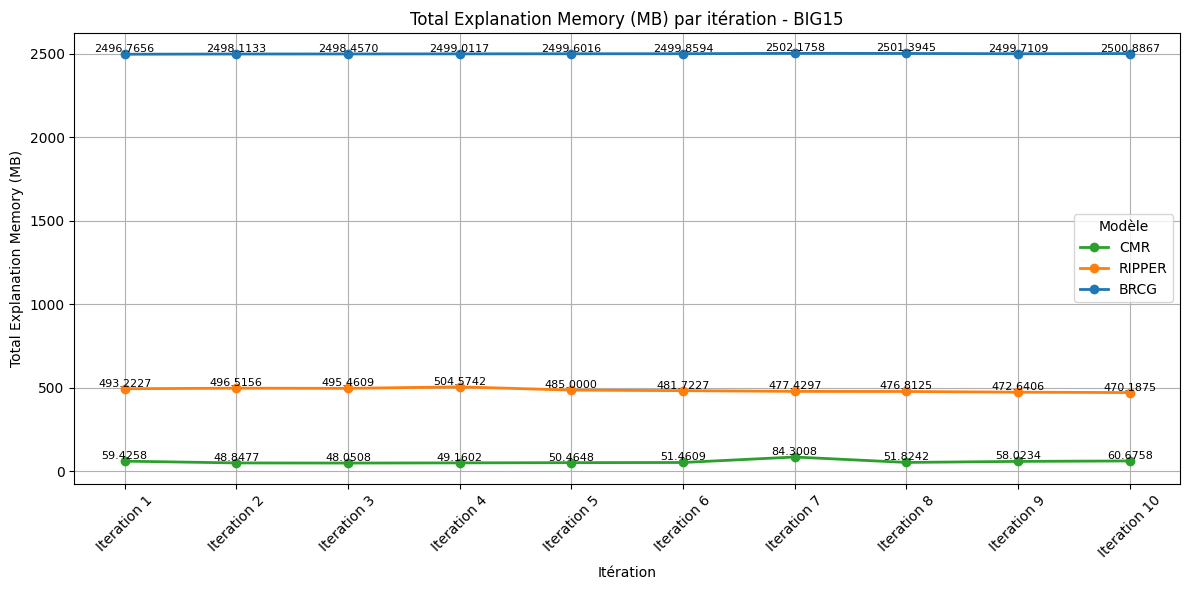

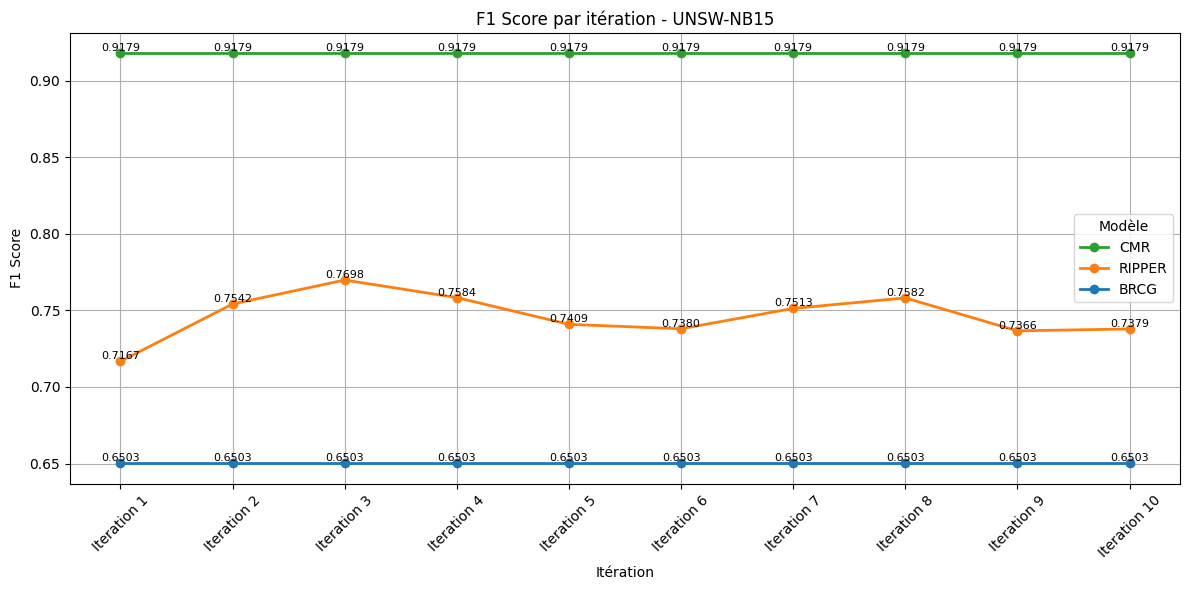

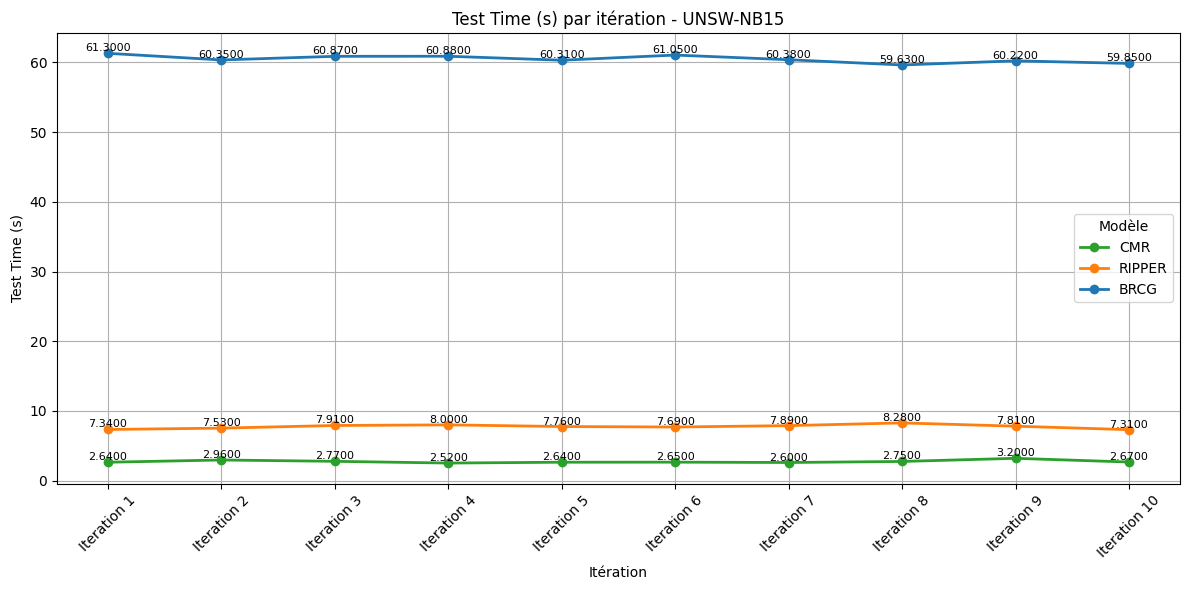

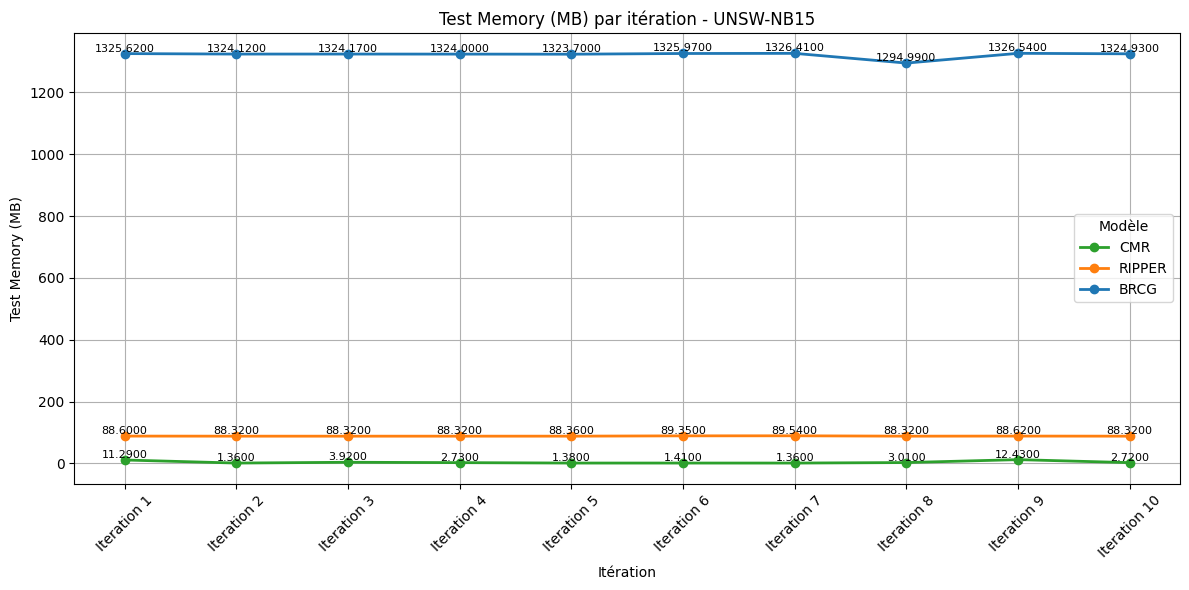

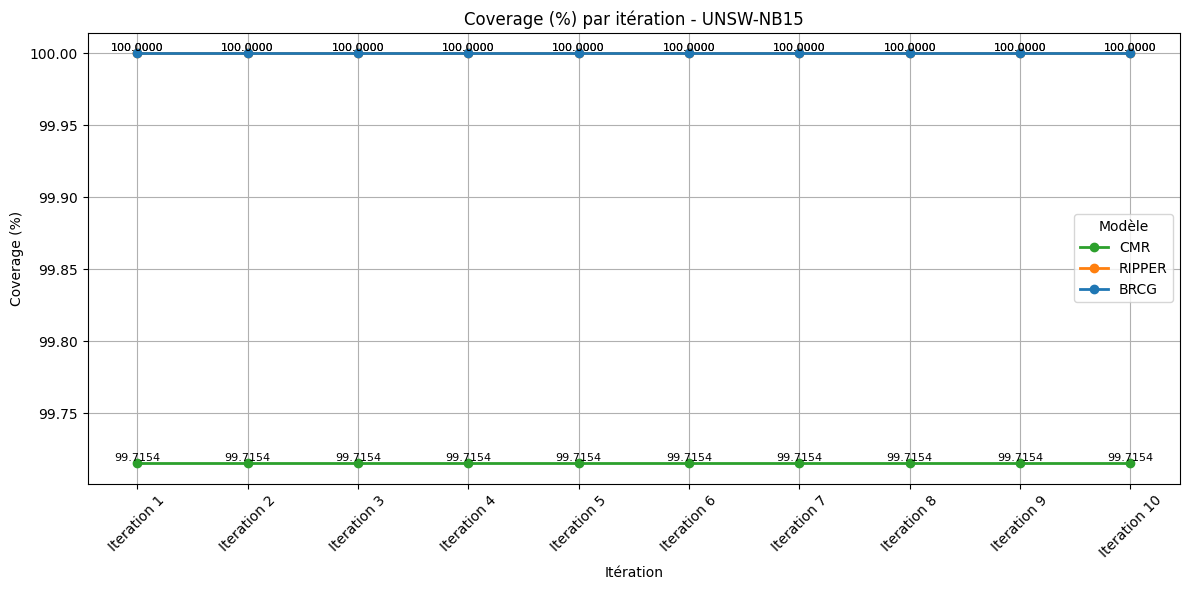

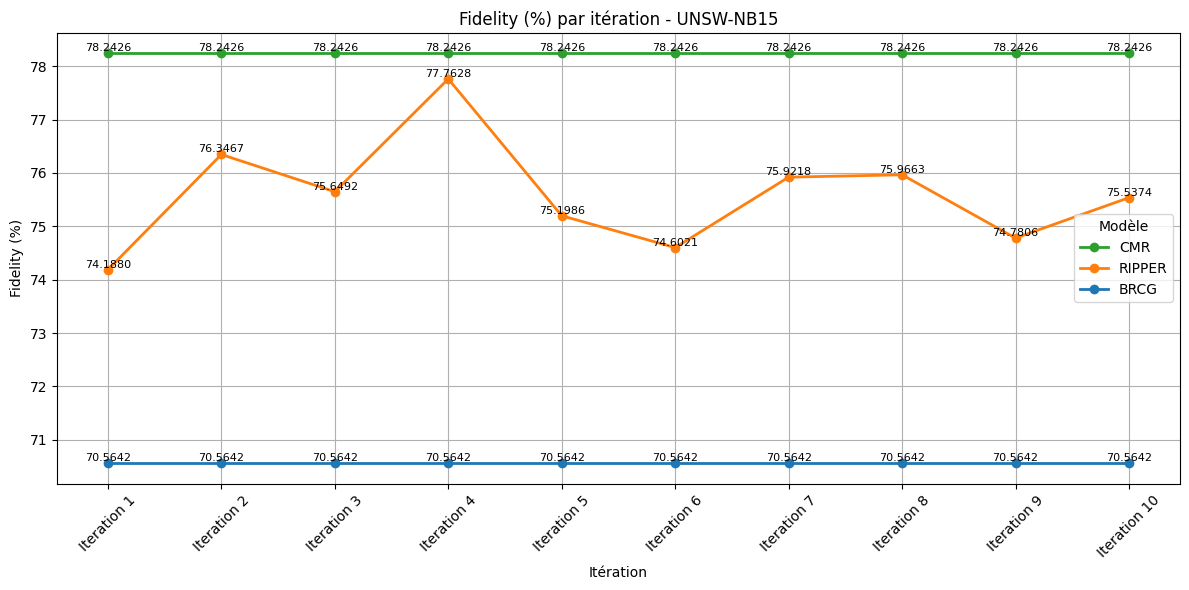

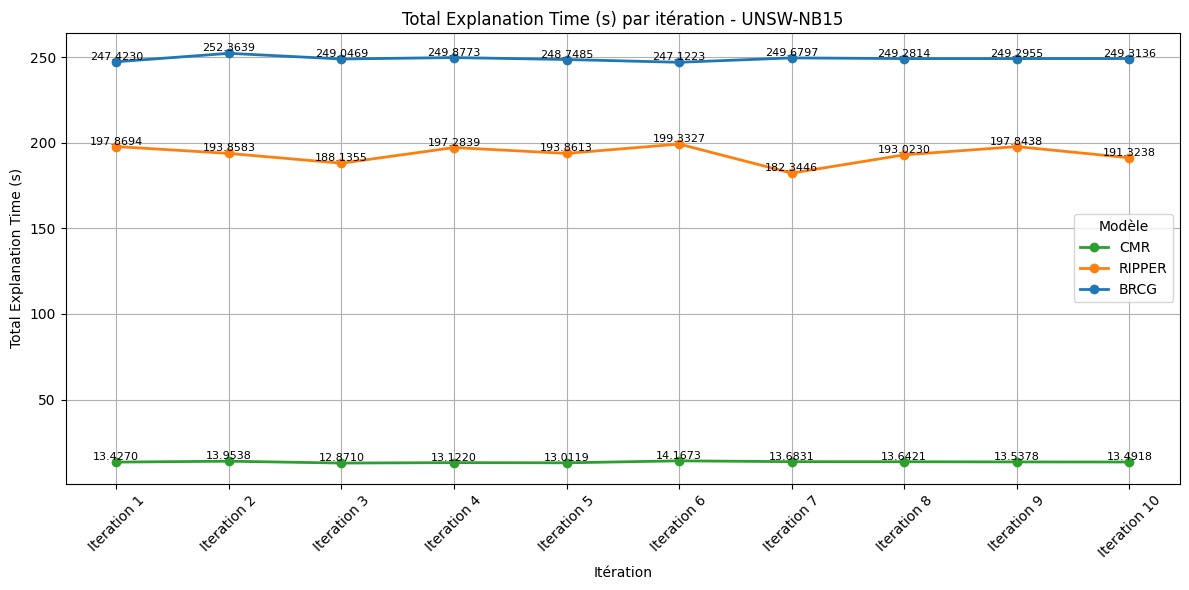

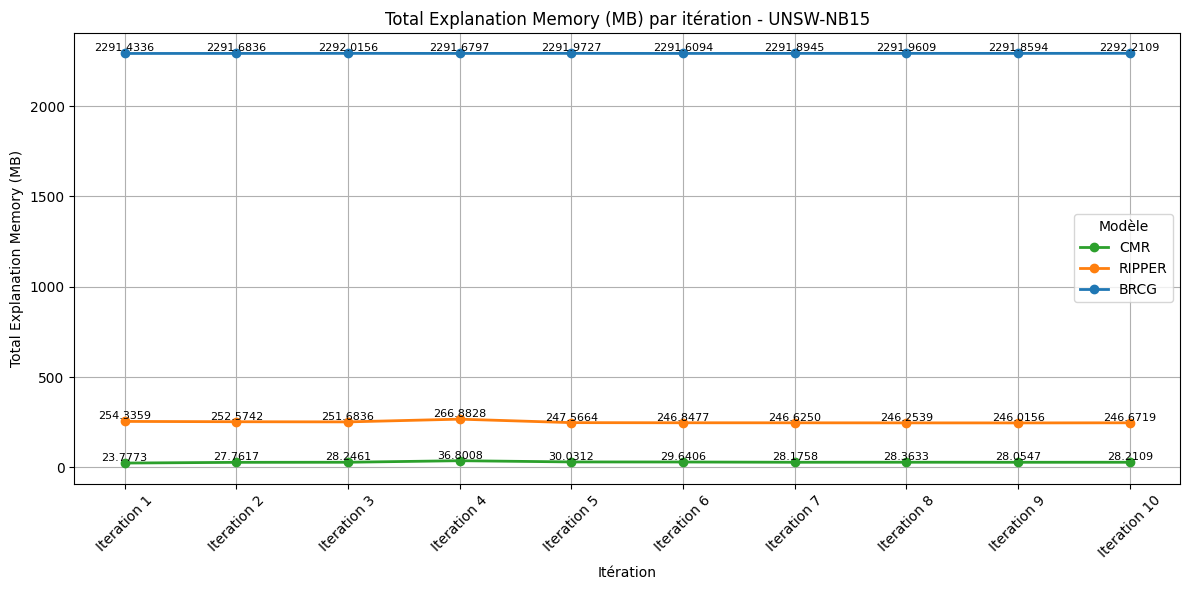

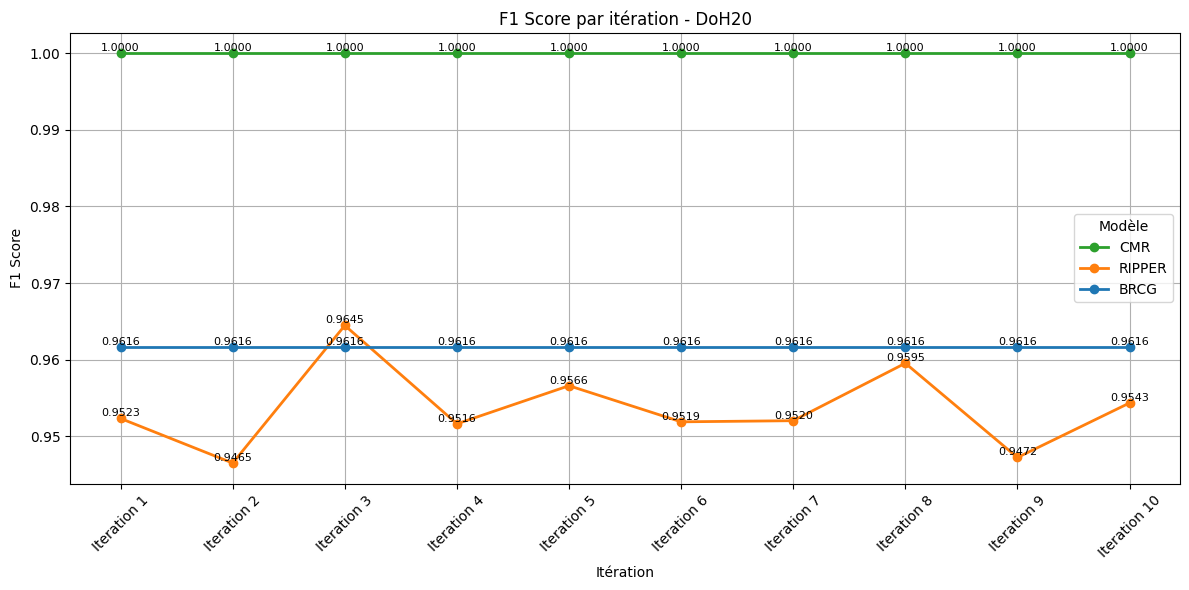

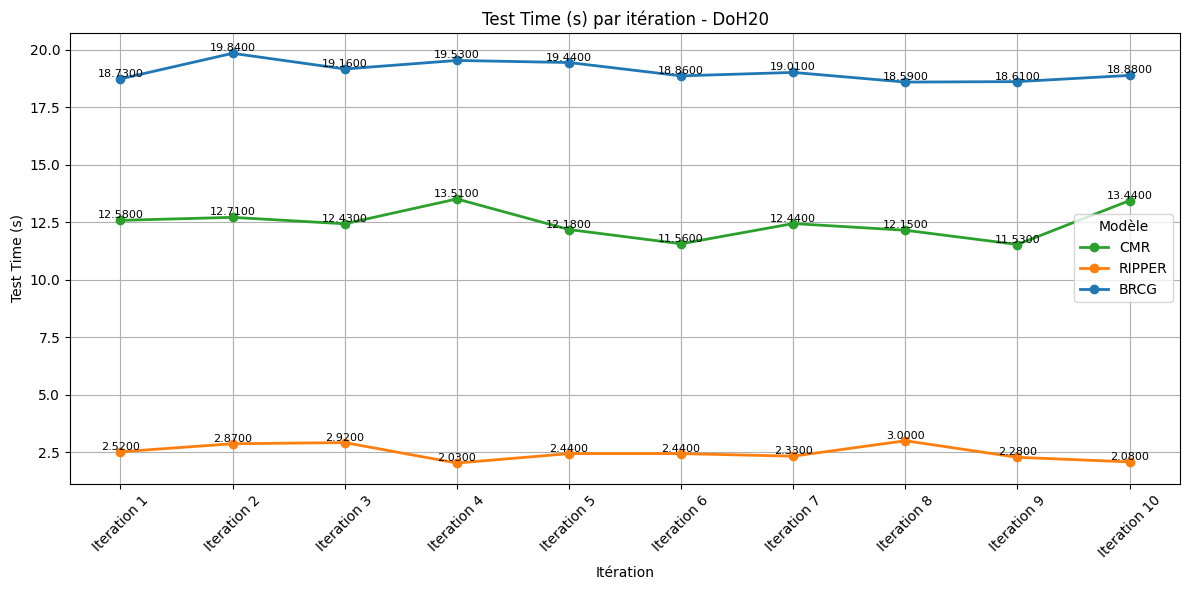

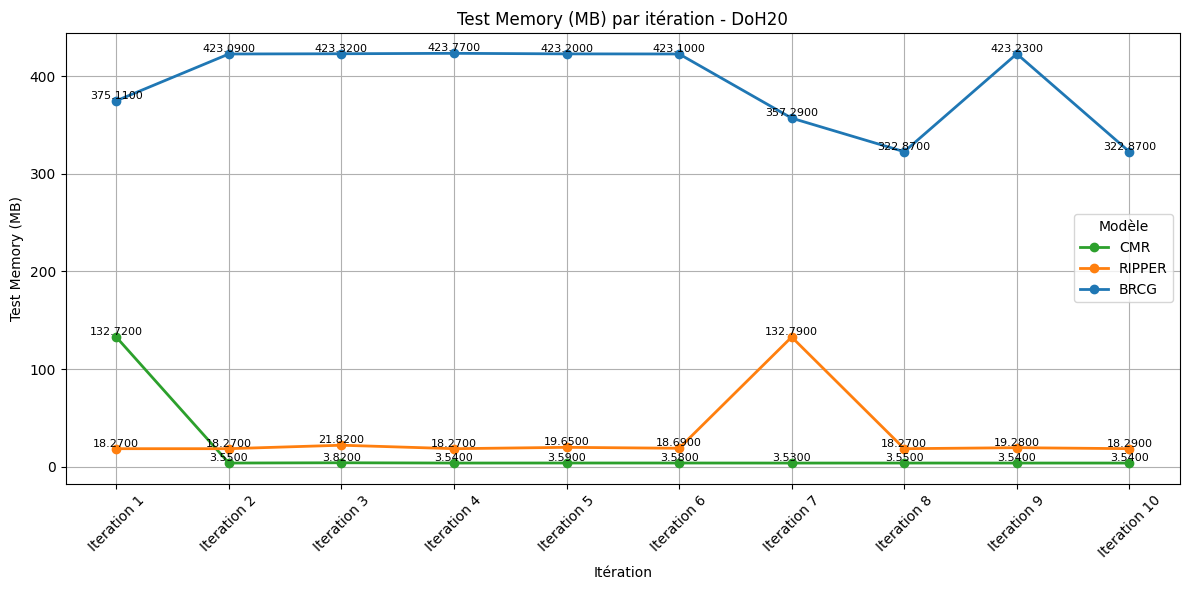

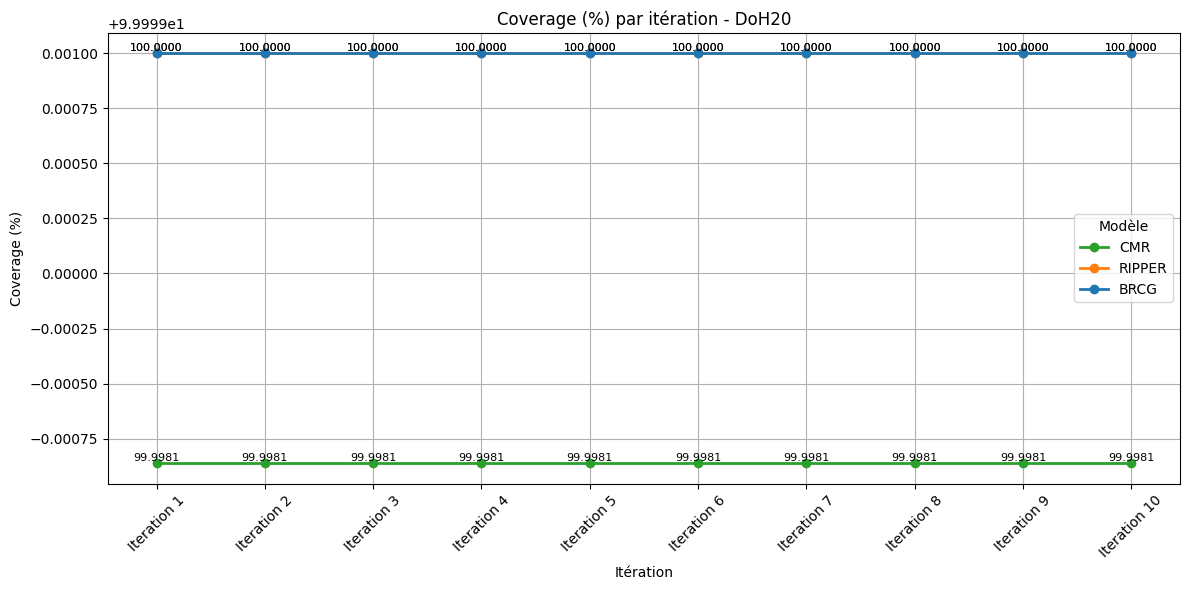

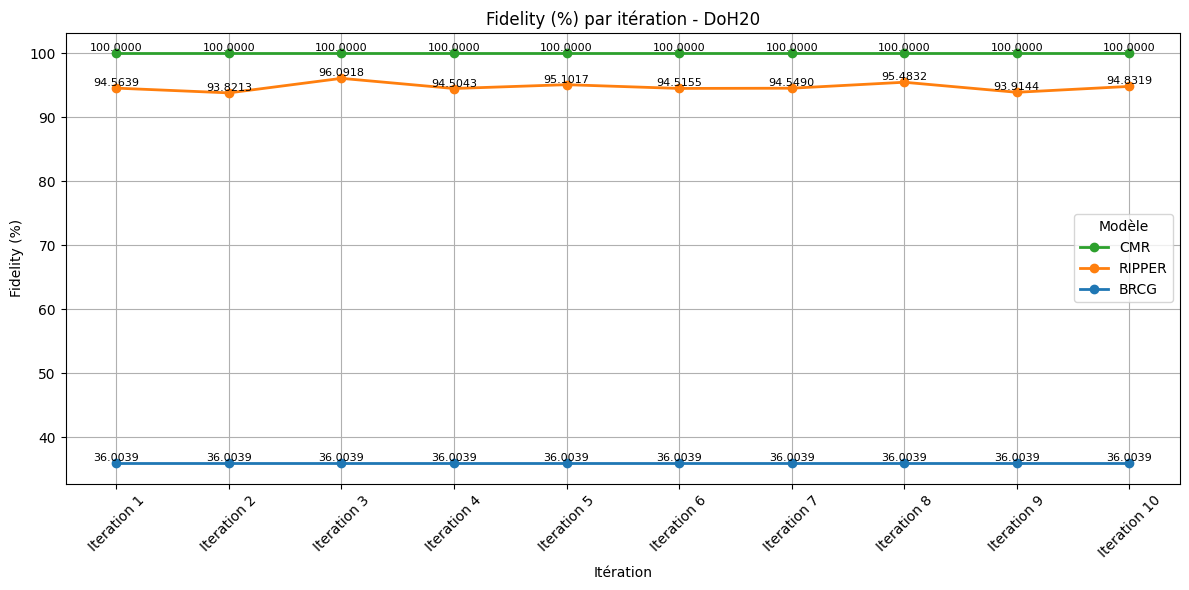

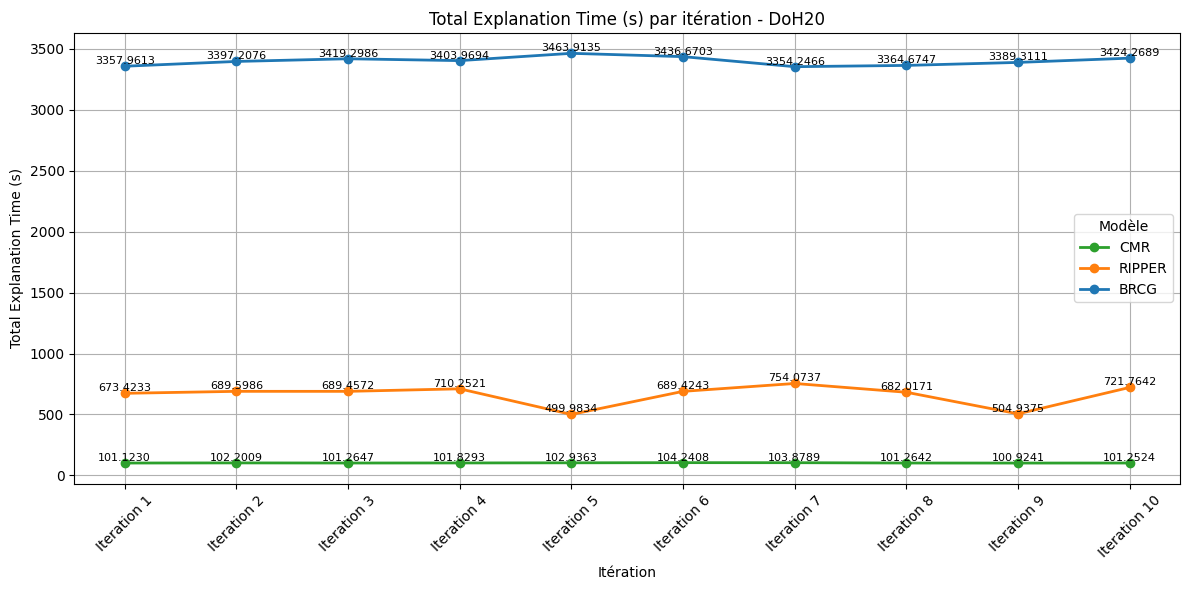

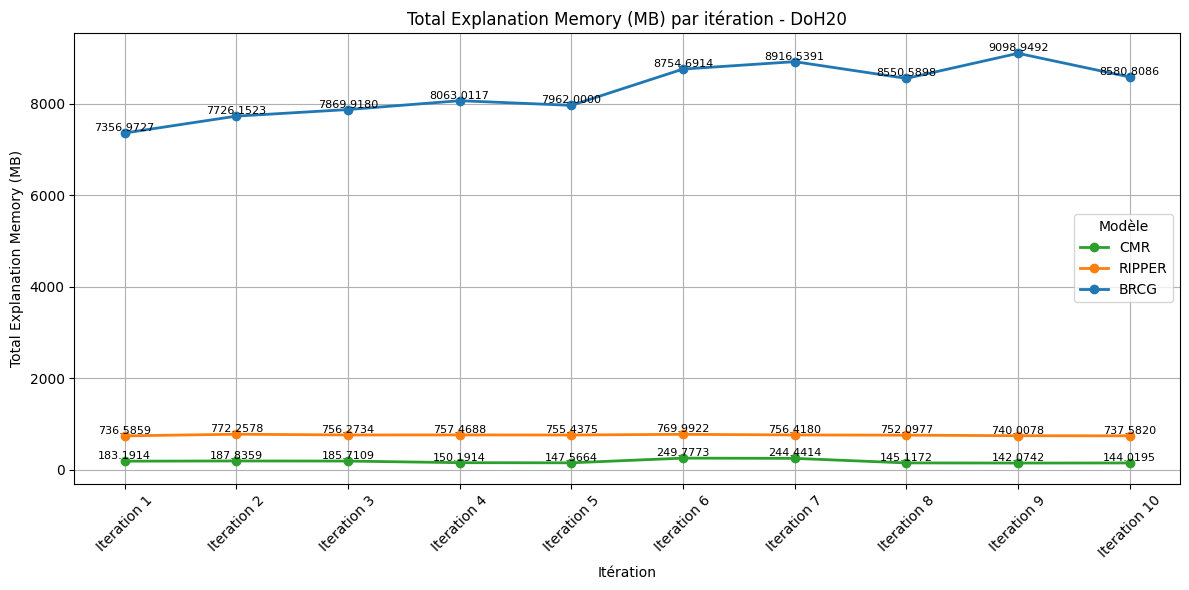

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("progress_iterations.csv", encoding="utf-8-sig")

df["Iteration"] = pd.to_numeric(df["Iteration"], errors="coerce")

metrics = [
    "F1_test",
    "Temps",
    "RAM_MB",
    "Coverage_total",
    "Fidelity_covered",
    "TT",
    "RAM_TT_MB"
]

metric_labels = {
    "F1_test": "F1 Score",
    "Temps": "Test Time (s)",
    "RAM_MB": "Test Memory (MB)",
    "Coverage_total": "Coverage (%)",
    "Fidelity_covered": "Fidelity (%)",
    "TT": "Total Explanation Time (s)",
    "RAM_TT_MB": "Total Explanation Memory (MB)"
}
colors = {
    "BRCG": "#1f77b4",
    "RIPPER": "#ff7f0e",
    "CMR": "#2ca02c"
}

datasets = df["Dataset"].unique()

os.makedirs("figures_line", exist_ok=True)

for dataset in datasets:
    df_dataset = df[df["Dataset"] == dataset].copy()

    for metric in metrics:
        plt.figure(figsize=(12, 6))

        for method in df_dataset["Méthode"].unique():
            subset = df_dataset[df_dataset["Méthode"] == method].sort_values("Iteration")

            x = subset["Iteration"]
            y = pd.to_numeric(subset[metric], errors="coerce")

            plt.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                label=method,
                color=colors.get(method, None)
            )

            for i, txt in enumerate(y):
                if pd.notna(txt):
                    plt.text(
                        x.iloc[i],
                        txt,
                        f"{txt:.4f}",
                        ha="center",
                        va="bottom",
                        fontsize=8
                    )


        plt.title(f"{metric_labels.get(metric, metric)} par itération - {dataset}")
        plt.xlabel("Itération")
        plt.ylabel(metric_labels.get(metric, metric))
        plt.xticks(range(1, 11), [f"Iteration {i}" for i in range(1, 11)], rotation=45)
        plt.grid(True)
        plt.legend(title="Modèle")
        plt.tight_layout()

        plt.savefig(f"figures_line/{dataset}_{metric}_line_values.png", dpi=300)
        plt.show()

## Graphique en barres

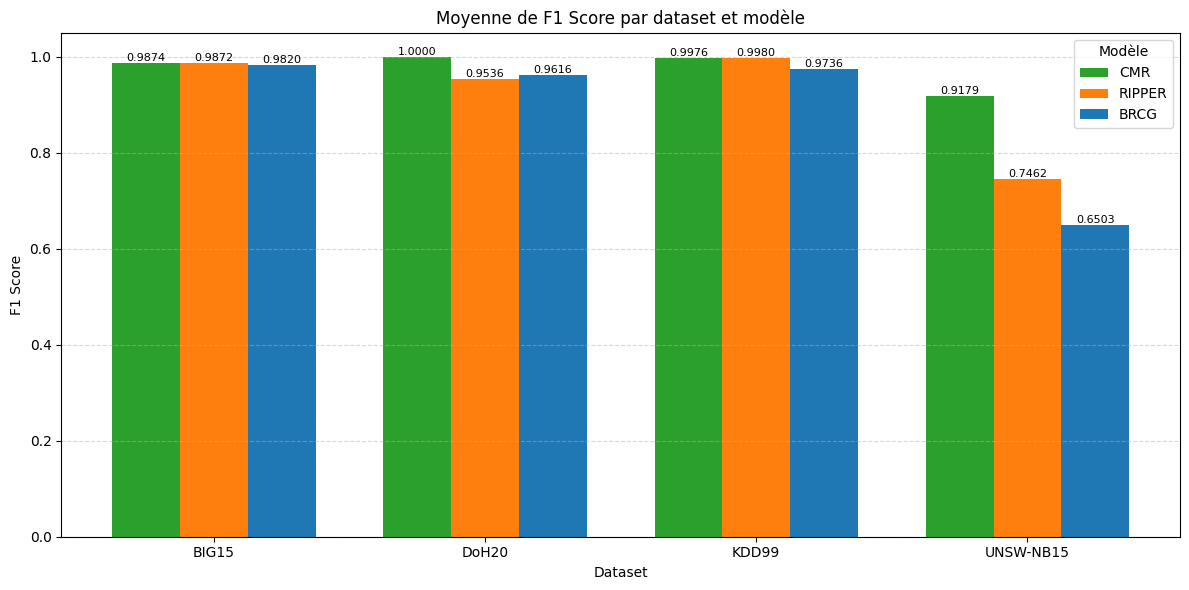

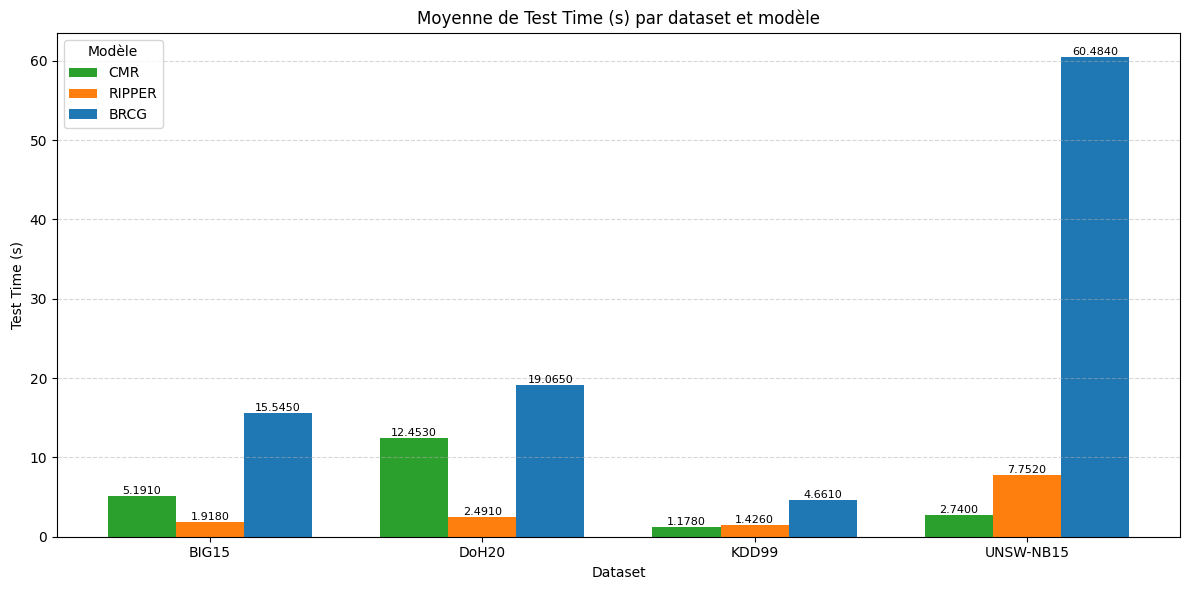

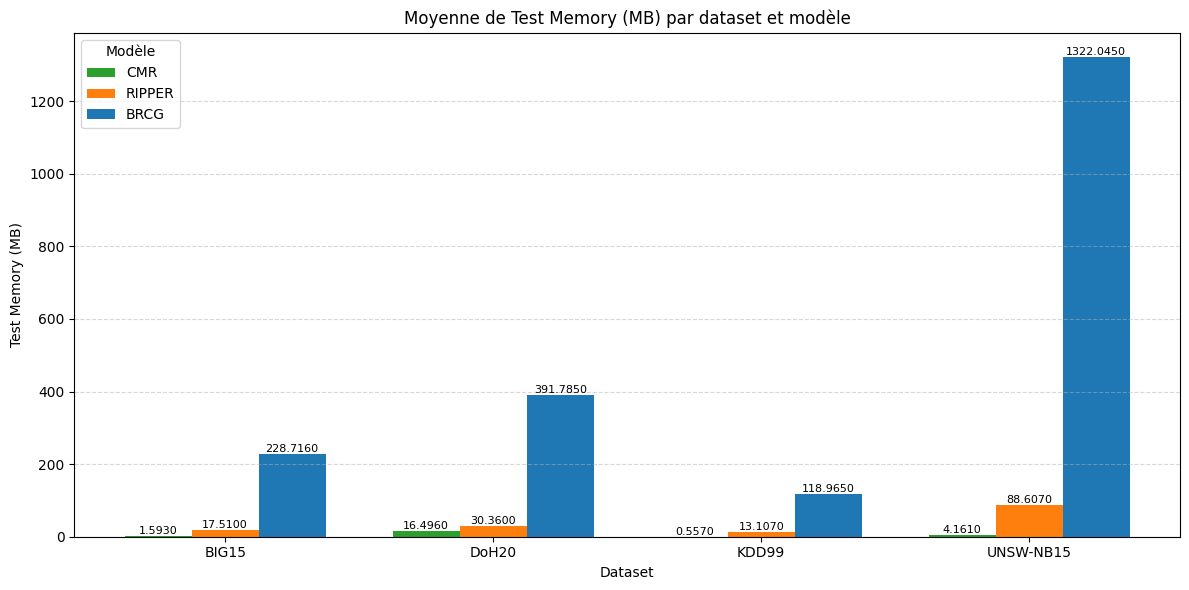

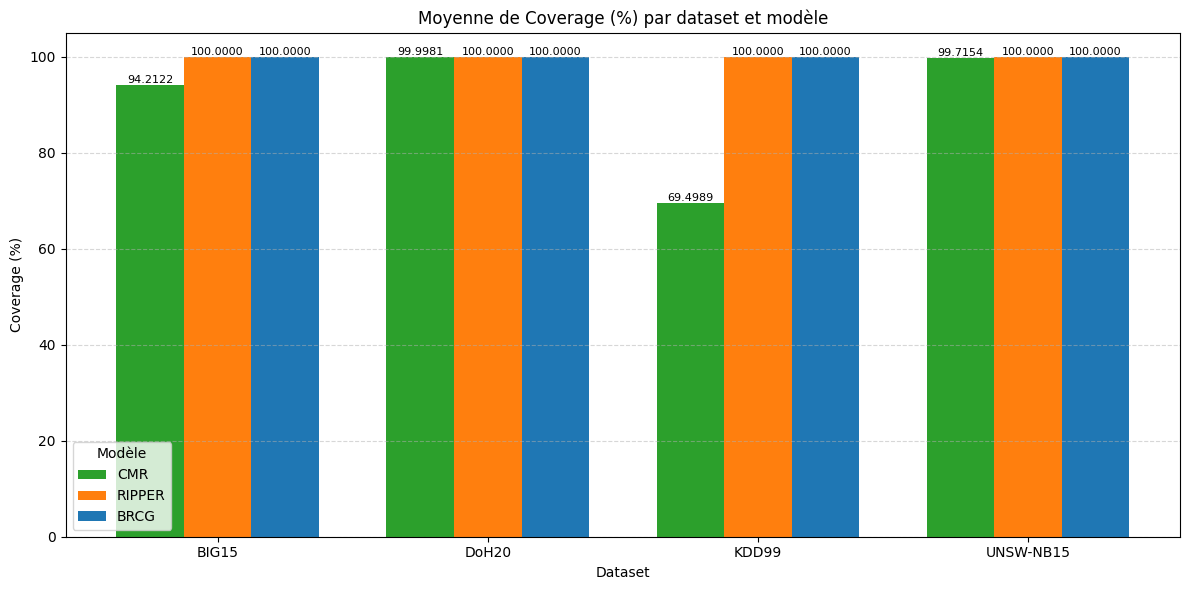

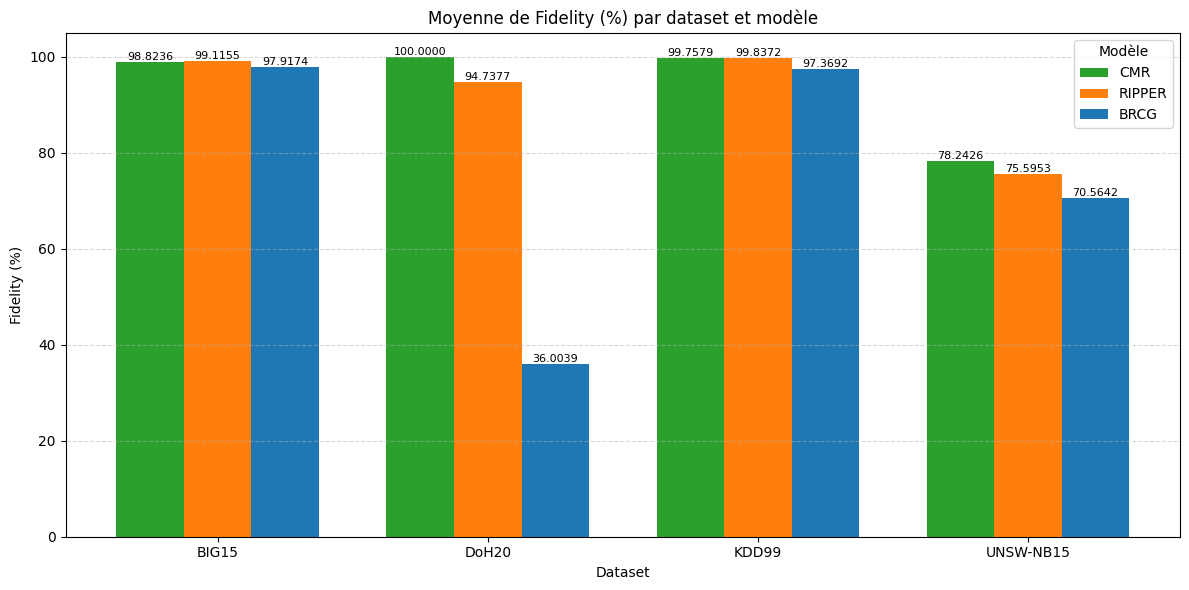

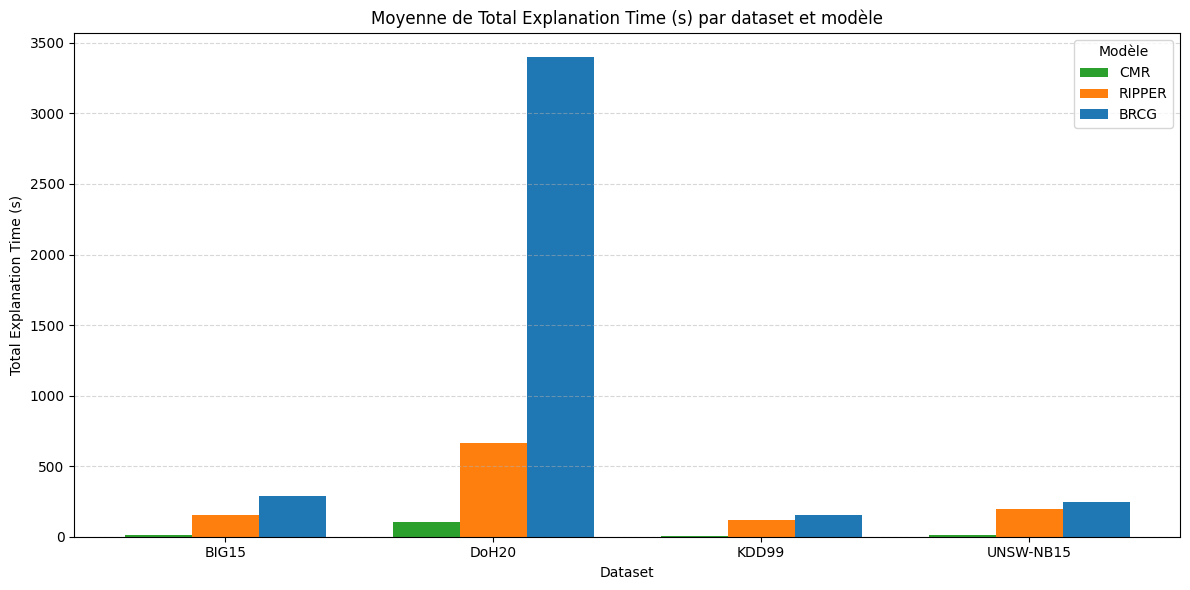

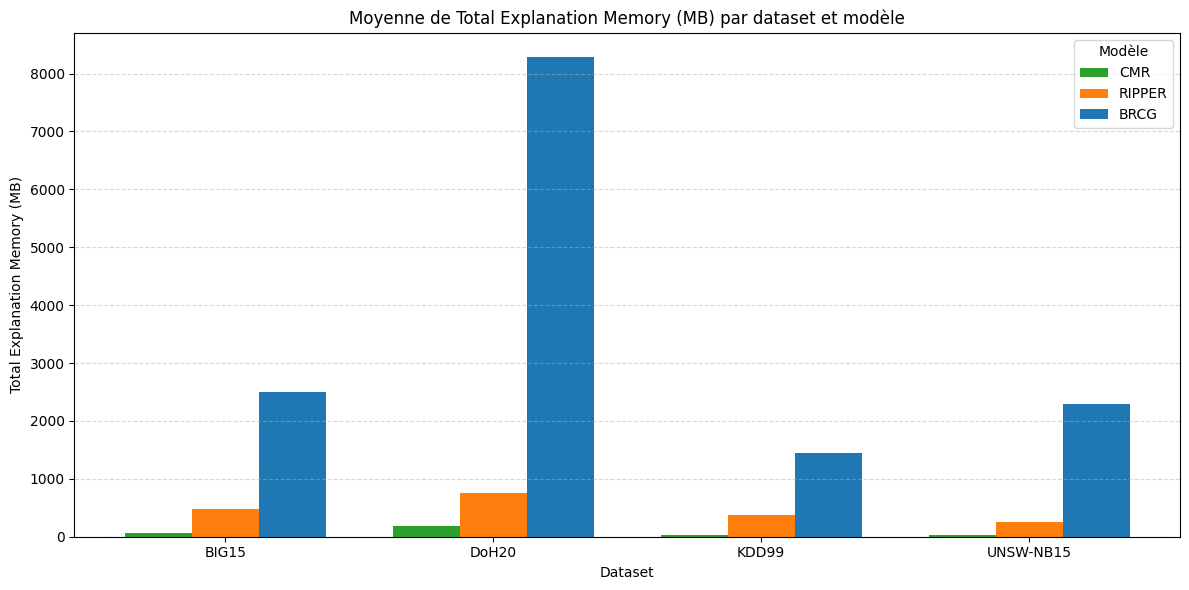

In [ ]:
import numpy as np

df_mean = (
    df.groupby(["Dataset", "Méthode"])
    .mean(numeric_only=True)
    .reset_index()
)

bar_metrics = [
    "F1_test",
    "Temps",
    "RAM_MB",
    "Coverage_total",
    "Fidelity_covered",
    "TT",
    "RAM_TT_MB"
]

metric_labels = {
    "F1_test": "F1 Score",
    "Temps": "Test Time (s)",
    "RAM_MB": "Test Memory (MB)",
    "Coverage_total": "Coverage (%)",
    "Fidelity_covered": "Fidelity (%)",
    "TT": "Total Explanation Time (s)",
    "RAM_TT_MB": "Total Explanation Memory (MB)"
}

os.makedirs("figures_bar", exist_ok=True)

for metric in bar_metrics:
    plt.figure(figsize=(12, 6))

    datasets = df_mean["Dataset"].unique()
    methods = ["CMR", "RIPPER", "BRCG"]

    x = np.arange(len(datasets))
    width = 0.25

    for i, method in enumerate(methods):
        subset = df_mean[df_mean["Méthode"] == method].set_index("Dataset")
        values = [subset.loc[d, metric] if d in subset.index else np.nan for d in datasets]

        plt.bar(
            x + i * width,
            values,
            width,
            label=method,
            color=colors.get(method, None)
        )

        if metric not in ["TT", "RAM_TT_MB"]:
            for j, value in enumerate(values):
                if pd.notna(value):
                    plt.text(
                        x[j] + i * width,
                        value,
                        f"{value:.4f}",
                        ha="center",
                        va="bottom",
                        fontsize=8
                    )

    plt.title(f"Moyenne de {metric_labels.get(metric, metric)} par dataset et modèle")
    plt.xlabel("Dataset")
    plt.ylabel(metric_labels.get(metric, metric))
    plt.xticks(x + width, datasets)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(title="Modèle")
    plt.tight_layout()

    plt.savefig(f"figures_bar/{metric}_bar_mean.png", dpi=300)
    plt.show()